<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/dice_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


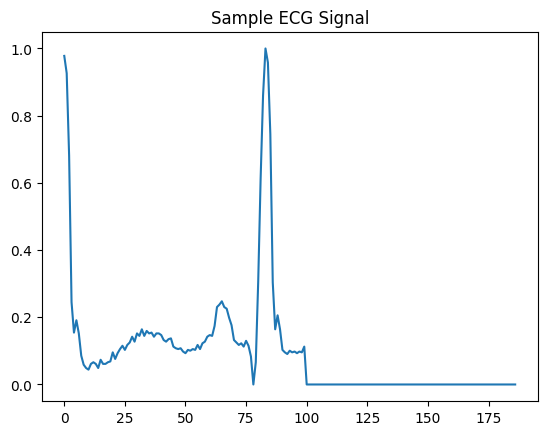

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

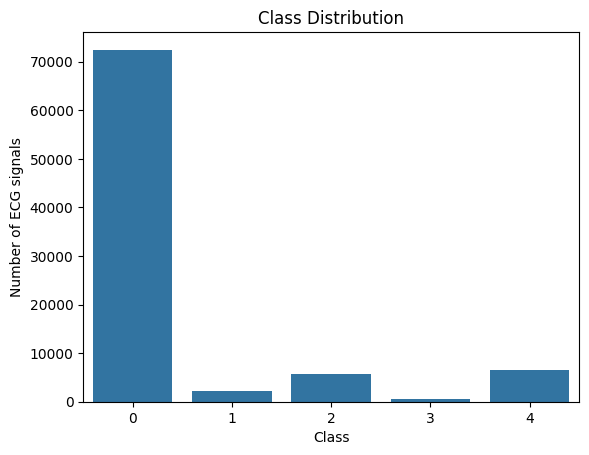

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def dice_loss(y_true, y_pred):

    smooth = 1e-7

    y_true = tf.cast(y_true, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)
    denominator = tf.reduce_sum(y_true + y_pred, axis=1)

    dice = (2 * intersection + smooth) / (denominator + smooth)

    return 1 - tf.reduce_mean(dice)

In [13]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=dice_loss,
        metrics=['accuracy']
    )

    return model

In [14]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 362s 95ms/step - accuracy: 0.9061 - loss: 0.0986
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 378s 94ms/step - accuracy: 0.9563 - loss: 0.0451
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 383s 94ms/step - accuracy: 0.9671 - loss: 0.0341
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 354s 94ms/step - accuracy: 0.9723 - loss: 0.0287
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 353s 94ms/step - accuracy: 0.9722 - loss: 0.0285

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 365s 95ms/step - accuracy: 0.9057 - loss: 0.0992
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 381s 95ms/step - accuracy: 0.9521 - loss: 0.0495
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 380s 95ms/step - accuracy: 0.9626 - loss: 0.0386
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 357s 95ms/step - accuracy: 0.9684 - loss: 0.0326
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 357s 94ms/step - accuracy: 0.9720 - loss: 0.0288

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 361s 94ms/step - accuracy: 0.9046 -

In [15]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 478s 104ms/step - accuracy: 0.9068 - loss: 0.0977 - val_accuracy: 0.8945 - val_loss: 0.1072
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 447s 99ms/step - accuracy: 0.9543 - loss: 0.0472 - val_accuracy: 0.8456 - val_loss: 0.1569
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 504s 99ms/step - accuracy: 0.9671 - loss: 0.0339 - val_accuracy: 0.9387 - val_loss: 0.0625
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 462s 102ms/step - accuracy: 0.9721 - loss: 0.0287 - val_accuracy: 0.7998 - val_loss: 0.2022
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 488s 99ms/step - accuracy: 0.9741 - loss: 0.0266 - val_accuracy: 0.9546 - val_loss: 0.0464
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 503s 99ms/step - accuracy: 0.9745 - loss: 0.0263 - val_accuracy: 0.9731 - val_loss: 0.0277
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 466s 103ms/step - accuracy: 0.9775 - loss: 0.0232 - val_accuracy: 0.9201 - val_loss: 0.0812
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 486s 99ms/step - accurac

Final Training Accuracy: 0.982944905757904
Final Validation Accuracy: 0.9486967325210571


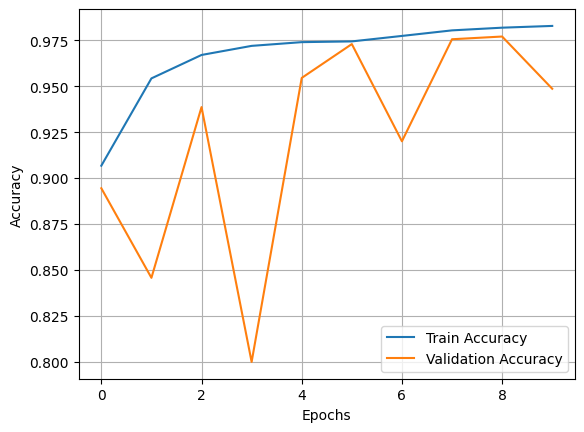

In [17]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Final Training Loss: 0.017539381980895996
Final Validation Loss: 0.051996197551488876


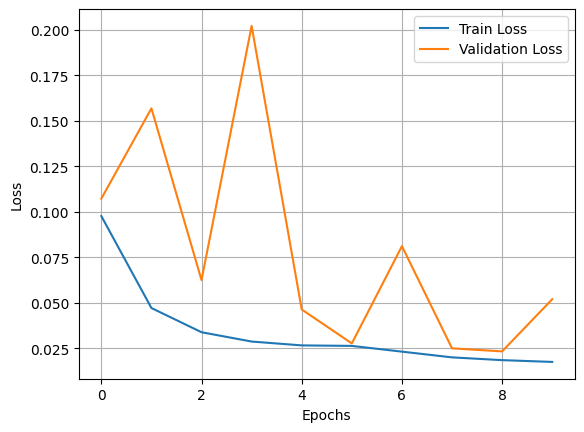

In [18]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.15712255239486694
Test Accuracy: 0.8444637060165405
685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.83      0.90     18118
         1.0       0.14      0.88      0.24       556
         2.0       0.94      0.92      0.93      1448
         3.0       0.58      0.88      0.70       162
         4.0       0.97      0.98      0.97      1608

    accuracy                           0.84     21892
   macro avg       0.72      0.89      0.75     21892
weighted avg       0.96      0.84      0.89     21892



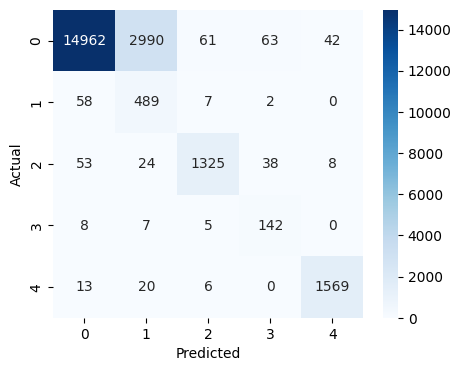

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()